In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from sklearn.metrics import auc

### Read saved results

In [2]:
cnn = pd.read_pickle("CNN_innv.pkl")
lstm = pd.read_pickle("LSTM_innv.pkl")
bi = pd.read_pickle("BiLSTM_innv.pkl")
cl = pd.read_pickle("CNN-LSTM_innv.pkl")
cbi = pd.read_pickle("CNN-BiLSTM_innv.pkl")

In [3]:
def visualization(model, seq, seq_val, method, prob):
  fig, ax = plt.subplots(5, 3, gridspec_kw={'width_ratios': [1, 8, 1]}, figsize=(10, 3) )

  for i in range(5):
    ax[i,0].text(0.5, 0.5, model[i]+'\n'+method[i], size=10, va="center", color="black")
    ax[i,0].axis('off')
    
    ax[i,1].imshow([seq_val[i]], cmap='Blues', interpolation='nearest') #np.reshape(seq_val[i], (1,20))
    for j in range(20):
      text = ax[i,1].text(j, 0, seq[j], size=12, ha="center", va="center", color="black")
    ax[i,1].axis('off')

    ax[i,2].text(-1, 0.5, 'Binding prob : \n'+str(round(prob[i],2)), size=10, va="center", color="black")
    ax[i,2].axis('off')

  fig.tight_layout()
  plt.axis('off')
  plt.subplots_adjust(hspace = 0.001)
  plt.show()

In [4]:
model = ['CNN', 'LSTM', 'BiLSTM', 'CNN-LSTM', 'CNN-BiLSTM']
seq_1 = cnn.seq[1]
seq_val_1 = [cnn.seq_val[8], lstm.seq_val[0], bi.seq_val[0], cl.seq_val[8], cbi.seq_val[7]]
method_1 = [cnn.method[8][1], lstm.method[0][1], bi.method[0][1], cl.method[8][1], cbi.method[7][1]]
prob_1 = [cnn.prob[0], lstm.prob[0], bi.prob[0], cl.prob[0], cbi.prob[0]]

In [5]:
model = ['CNN', 'LSTM', 'BiLSTM', 'CNN-LSTM', 'CNN-BiLSTM']
seq_2 = cnn.seq[10]
seq_val_2 = [cnn.seq_val[18], lstm.seq_val[10], bi.seq_val[9], cl.seq_val[18], cbi.seq_val[16]]
method_2 = [cnn.method[18][1], lstm.method[10][1], bi.method[9][1], cl.method[18][1], cbi.method[16][1]]
prob_2 = [cnn.prob[10], lstm.prob[10], bi.prob[10], cl.prob[10], cbi.prob[10]]

### Comparison
Analyzer for CNN / CNN-RNN models : LRP sequential present A flat

Analyzer for RNN models : Gradient

sequence 1 : 'TTGCGGAACCGGTTTTACTA'

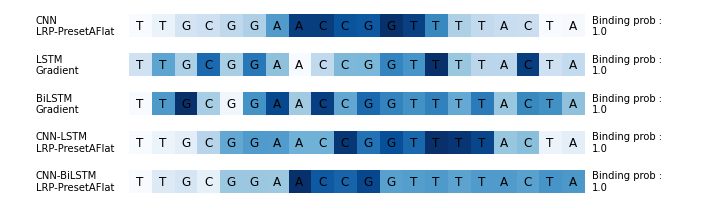

In [6]:
visualization(model, seq_1, seq_val_1, method_1, prob_1)

sequence 2 : 'AATCAGGAGTAACCGGTTTC' 

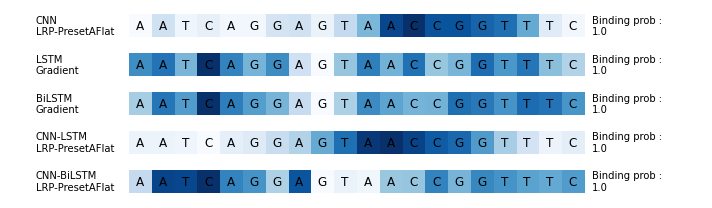

In [7]:
visualization(model, seq_2, seq_val_2, method_2, prob_2)